# Lasso Regression with Information Criteria

This notebook performs Lasso regression on the diabetes dataset to demonstrate feature selection via information criteria:
1. Loading the diabetes dataset and adding random features
2. Standardizing the features for optimal performance
3. Training Lasso models with varying regularization strengths
4. Evaluating models using AIC and BIC information criteria
5. Visualizing the impact of the alpha parameter on model selection

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso

## Load and Prepare Data

The diabetes dataset is augmented with 14 random features to make feature selection more relevant, then all features are standardized.

In [2]:
X, y = load_diabetes(return_X_y=True)

rng = np.random.RandomState(42)
n_random_features = 14
X_random = rng.randn(X.shape[0], n_random_features)
X = np.c_[X, X_random]

X_avg = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_avg) / X_std

## Information Criteria Functions

AIC (Akaike) and BIC (Bayesian) penalize model complexity differently — BIC uses a stronger penalty that grows with sample size. Both prefer models with lower scores.

In [ ]:
def AIC(y_true, y_pred, k):
    # AIC = n * log(RSS/n) + 2k
    n = len(y_true)
    rss = ((y_true - y_pred) ** 2).sum()
    return n * np.log(rss / n) + 2 * k

def BIC(y_true, y_pred, k):
    # BIC = n * log(RSS/n) + k * log(n)
    n = len(y_true)
    rss = ((y_true - y_pred) ** 2).sum()
    return n * np.log(rss / n) + k * np.log(n)

## Train Models Across Alpha Values

For each regularization strength, the number of non-zero coefficients is used as the effective model complexity `k`.

In [4]:
scores_aic = []
scores_bic = []
alphas = np.logspace(-2, 2, 100)

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X, y)
    y_pred = lasso.predict(X)
    k = np.sum(lasso.coef_ != 0) + 1  # non-zero features + intercept
    scores_aic.append(AIC(y, y_pred, k))
    scores_bic.append(BIC(y, y_pred, k))

## Visualize Information Criteria

The optimal alpha minimizes the information criterion. The geometric mean of AIC and BIC provides a balanced selection criterion.

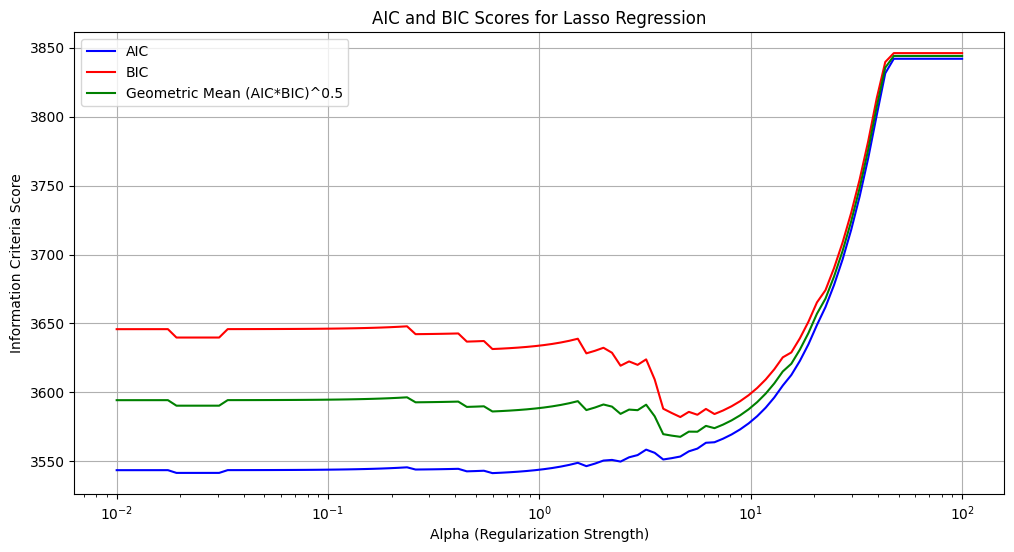

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(alphas, scores_aic, label='AIC', color='blue')
plt.plot(alphas, scores_bic, label='BIC', color='red')
plt.plot(alphas, np.sqrt([scores_aic[i] * scores_bic[i] for i in range(len(alphas))]),
         label='Geometric Mean (AIC*BIC)^0.5', color='green')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('Information Criteria Score')
plt.title('AIC and BIC Scores for Lasso Regression')
plt.legend()
plt.grid()
plt.show()